# Explore Semantic Similarity

This notebook goes through the developement of the semantic similarity functions and demonstrates their uses.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from MovieData import MovieData

In [3]:
md = MovieData()

## Generate Semantic Similarity Matricies

This is the code to generate the semantic similarity scores between the genres and the keywords. These matricies have already been made, so you don't need to run this! It's for posterity and education.

We used the SpaCy (https://spacy.io/) language models. In order to have the word vectors, you need either the medium or the large model. I found that the medium model was sufficient. If you use the large model, you can probably made the similarities a bit more accurate.

In order to use the language models, you'll need to download them seperately. More information is found here (https://spacy.io/usage/models), but in short, install `spacy` and run

`python -m spacy download en_core_web_md`

(If you ever want to un-download these models, you can use spacy-installer: https://github.com/rtmigo/spacy_installer_py).

In [1]:
import spacy
from tqdm import tqdm

In [2]:
nlp = spacy.load("en_core_web_md")
#nlp = spacy.load("en_core_web_lg")

### Genres Similarity

The first step for me was to check if the words were actually in the SpaCy vocab list.

In [11]:
genres = md.get_genres()
n_genres = len(genres)

In [12]:
words = set(nlp.vocab.strings)
oov_count = 0
for genre in genres:
    doc = nlp(str(genre))
    for word in doc:
        if word.is_oov: 
            print(word, 'is not in the language dictionary')
            oov_count += 1
if oov_count == 0: print('All genres are in the language dictionary')

All genres are in the language dictionary


Since all the genres are in vocab, we can make the similarity matrix and save it. This isn't an executable to prevent accidents. You can load in the saved one below.

In [7]:
genre_similarity = np.loadtxt('similarity_matrices/genre.csv', delimiter=',')

Let's plot the semantic similarities.

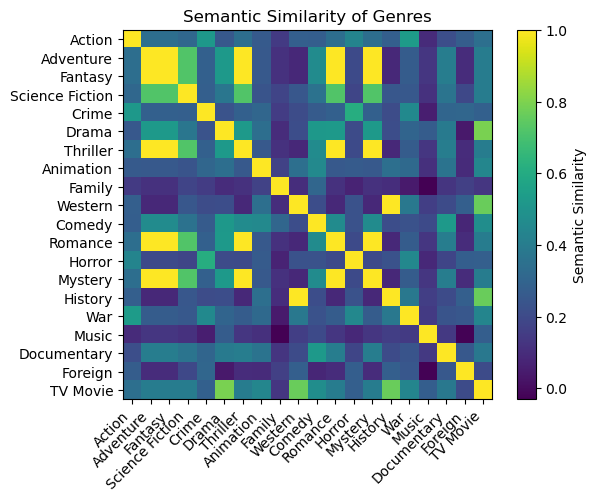

In [10]:
fig, ax = plt.subplots()
cax = ax.matshow(genre_similarity)
ax.xaxis.set_ticks_position("bottom")
ax.set_xticks(np.arange(n_genres), genres, rotation=45, ha='right')
ax.set_yticks(np.arange(n_genres), genres, ha='right')
fig.colorbar(cax, ax=ax, label='Semantic Similarity')
ax.set_title('Semantic Similarity of Genres');
#fig.savefig('genre_similarity.png');

### Keywords Similarity

Now, we do the same process with the keywords. There are a *lot* of keywords, so this is a very time consuming operation. It took about 36 hours to generate the similarity matrix on Skylar's computer. 

First, we check if they are in-vocab.

In [13]:
keywords = md.get_keywords()

In [15]:
oov_words = []
for keyword in tqdm(keywords):
    doc = nlp(str(keyword))
    for word in doc:
        if word.is_oov: 
            oov_words.append(word)

print('There are', len(oov_words), 'out-of vocabulary words in the keywords.')
percent_oov = 100*(len(oov_words) / len(keywords) )
print(f'That is {percent_oov:1.2f}% of the keywords.')

100%|██████████████████████████████████████| 9813/9813 [00:24<00:00, 401.70it/s]

There are 182 out-of vocabulary words in the keywords.
That is 1.85% of the keywords.


This is actually an overestimate of the percentage of out-of-vocab (oov) words because this was counting oov tokens and dividing by total keywords and there are more total tokens than there are total keywords. Given that the over-estimate is still so small, we decided that was sufficient. You can look through the list of oov words, and a lot of them are acronyms, misspellings, and non-english words. That seemed acceptable, and also like it wouldn't be solved by getting a larger model.

In [17]:
oov_words

[aftercreditsstinger,
 duringcreditsstinger,
 myoko,
  ,
  ,
 baustelle,
 q*bert,
 apprendista,
  ,
 guantánamo,
 symbologist,
 galier,
 fabergé,
 eastindian,
  ,
  ,
 carolinam,
 glaciale,
  ,
 metereologist,
  ,
 lovesickness,
 vororte,
  ,
 overleven,
 bulldogg,
 lasergun,
 kubakrise,
 m.i.t,
 quatermain,
 ailul,
 raumschiffabsturz,
 nixe,
 laserpointer,
  ,
 thalassophobia,
 cattivissimo,
 wettermann,
 s.a.t,
 polynésie,
 reprioritizing,
 turboman,
 downworlder,
 shadowhunter,
 perónism,
  ,
   ,
 lasersight,
 cojote,
 mercifulness,
 orléans,
 preisgeld,
 teuflisch,
 rumpelstilzchen,
 autoritian,
 beforecreditsstinger,
 toxication,
 unsociability,
 urteil,
 chefin,
 valak,
 oberflächlichkeit,
 Γη,
 yucatec,
 schönbrunn,
  ,
 sexappeal,
 beförderung,
 discontentedness,
 displeasedness,
 strugatsky,
 testting,
  ,
 sexchat,
 tarkovskyesque,
 绝地奶霸,
 卧底肥妈,
 big爆任务,
 超级妈妈,
  ,
 ordensbruder,
 bronko,
 nagurski,
 coaction,
 pleite,
 s.w.a.t,
 immoderateness,
 englishwoman,
 hemophagia,
 

Once again, I removed the ability to execute this to prevent accidents.

In [18]:
keyword_similarity = np.loadtxt('similarity_matrices/keywords.csv', delimiter=',')

There are far too many keywords for the similarity matrix to be "human readable." However, we show it here as a sanity check. There are 1's along the diagonal, and the values are in fact differnt from one another.

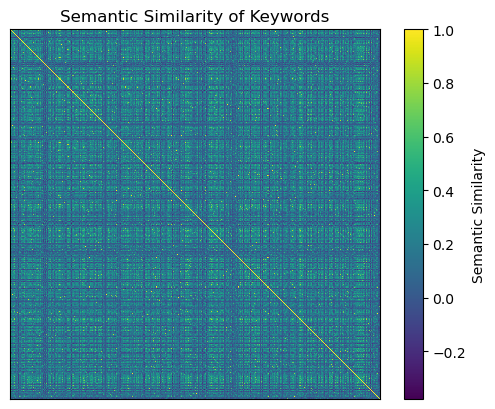

In [20]:
fig, ax = plt.subplots()
cax = ax.matshow(keyword_similarity)
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(cax, ax=ax, label='Semantic Similarity')
ax.set_title('Semantic Similarity of Keywords');
#fig.savefig('keyword_similarity.png');

## Similarity Functions

Now, we can look at the similarity functions defined on these matricies.

In [4]:
from similarity import semantic_similarity, semantic_similarity_plot

In [5]:
genre_similarity = np.loadtxt('similarity_matrices/genre.csv', delimiter=',')
keyword_similarity = np.loadtxt('similarity_matrices/keywords.csv', delimiter=',')

I manually selected some movies that yeild interesting results for you to play with.

In [6]:
idx1 = 17 #Pirates of the Caribbean: On Stranger Tides
idx2 = 12 #Pirates of the Caribbean: Dead Man's Chest
idx3 = 6 #Tangled
idx4 = 118 #Ratatouille
idx5 = 124 #Frozen
idx6 = 129 #Thor

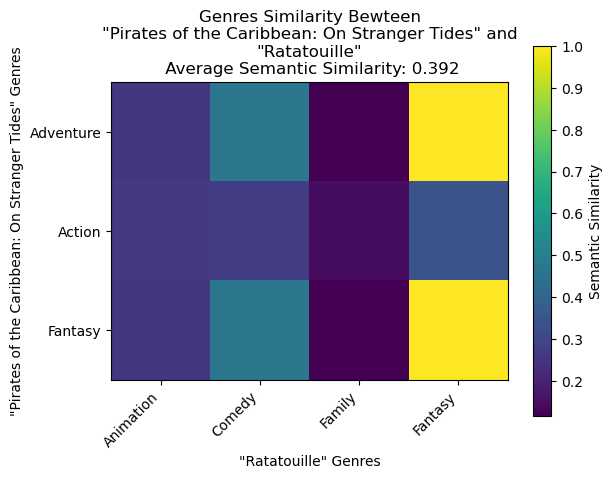

In [12]:
semantic_similarity_plot(row1=idx1, row2=idx4, attribute='genres', similarity_matrix=genre_similarity, moviedata=md, savepath=None)

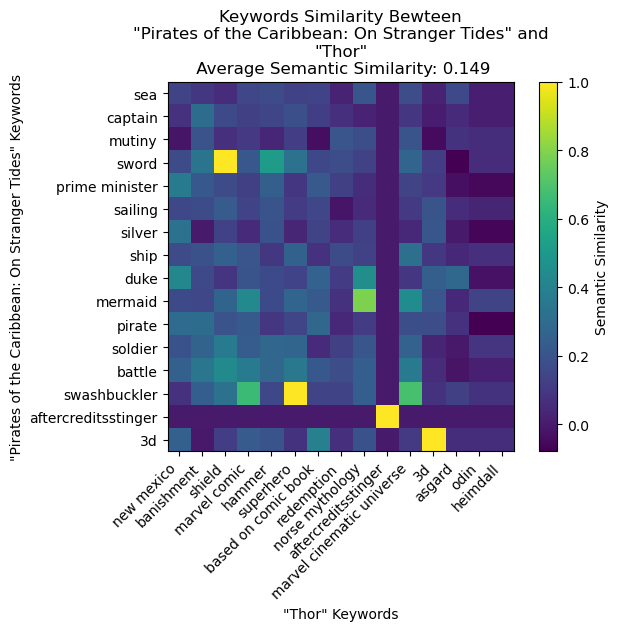

In [13]:
semantic_similarity_plot(row1=idx1, row2=idx6, attribute='keywords', similarity_matrix=keyword_similarity, moviedata=md, savepath=None)